<a href="https://colab.research.google.com/github/Zainabshiha/Diabetes-type-2-prediction-using-CNN-Conv-KAN/blob/main/Traditional_CNN_Model_T2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Conv2D, MaxPooling1D,MaxPooling2D, Flatten, Dense, BatchNormalization, Dropout, Reshape
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, RMSprop
from tensorflow.keras import regularizers
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# prompt: read_csv file

import pandas as pd
final_data = pd.read_csv('/content/drive/MyDrive/Prediction_T2D/final_data.csv')

In [ ]:
# Assuming 'Output' is your target variable
X = final_data.drop(['Output', 'Sample'], axis=1)

y = final_data['Output']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

# Scaling numerical features
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

print("X_Total shape:", X.shape)
print("X_train shape:", X_train_scaler.shape)
print("X_test shape:", X_test_scaler.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_Total shape: (126, 31061)
X_train shape: (107, 31061)
X_test shape: (19, 31061)
y_train shape: (107,)
y_test shape: (19,)


In [ ]:

# Reshaping the data to 2D
X_train_cnn = X_train_scaler.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test_cnn = X_test_scaler.reshape(X_test.shape[0], X_test.shape[1], 1)

# Building the CNN model
model = Sequential([
            Reshape((X_train_scaler.shape[1], 1, 1), input_shape=(X_train_scaler.shape[1], 1)),

            #Conv2D(16, (3, 1), activation='relu'),
            Conv2D(8, (3, 1), activation='relu'),
             Conv2D(16, (3, 1), activation='relu'),
            #Conv2D(32, (3, 1), activation='relu'),


            MaxPooling2D((2, 1)),
            Dropout(0.5),
            Flatten(),
             #Dense(128, activation='relu'),
            Dense(16, activation='relu'),
            #Dense(8, activation='relu'),
             #Dense(8, activation='relu'),
            Dropout(0.5),

            Dense(1, activation='sigmoid')
])

# Compile the model with a lower learning rate and a different optimizer
model.compile(optimizer=Adam(0.00001), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()



/usr/local/lib/python3.10/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ reshape_9 (Reshape)                  │ (None, 31061, 1, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 31059, 1, 8)         │              32 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 31057, 1, 16)        │             400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 15528, 1, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 15528, 1, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 248448)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 16)                  │       3,975,184 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,975,633 (15.17 MB)

 Trainable params: 3,975,633 (15.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#from tensorflow.keras.callbacks import EarlyStopping  # Import EarlyStopping
#early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
#patience=5
#callbacks=[early_stopping]
# Train the model with increased epochs and a smaller validation split
history = model.fit(X_train_scaler, y_train, epochs=90, batch_size=32, validation_split=0.15)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_scaler, y_test, verbose=2)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

Epoch 1/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6376 - loss: 0.6547 - val_accuracy: 0.4706 - val_loss: 0.6936
Epoch 2/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 651ms/step - accuracy: 0.5590 - loss: 0.7038 - val_accuracy: 0.4706 - val_loss: 0.6977
Epoch 3/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 651ms/step - accuracy: 0.4276 - loss: 0.7324 - val_accuracy: 0.4706 - val_loss: 0.6945
Epoch 4/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 633ms/step - accuracy: 0.6014 - loss: 0.6760 - val_accuracy: 0.4706 - val_loss: 0.6919
Epoch 5/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 644ms/step - accuracy: 0.5668 - loss: 0.6949 - val_accuracy: 0.4706 - val_loss: 0.6948
Epoch 6/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.5434 - loss: 0.6865 - val_accuracy: 0.4706 - val_loss: 0.6954
Epoch 7/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 627ms/step - accuracy: 0.4710 - loss: 0.6989 - val_accuracy: 0.4706 - val_loss: 0.6905
Epoch 8/90
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 657ms/step - accuracy: 0.6543 - loss: 0.6501 - val_accuracy: 0.4706 - val_loss: 0.68

In [ ]:
# prompt: Evaluate the  last model with F-score, recall, classification report, accuracy

from sklearn.metrics import f1_score, recall_score, classification_report, accuracy_score

# Assuming y_pred contains the predicted labels for the test set
y_pred = (model.predict(X_test_scaler) > 0.5).astype("int32")

# Calculate the F1-score
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")

# Calculate the recall
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall}")

# Generate the classification report
print(classification_report(y_test, y_pred))

# Calculate the accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
F1 Score: 0.9411764705882353
Recall: 0.8888888888888888
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.89      0.94         9

    accuracy                           0.95        19
   macro avg       0.95      0.94      0.95        19
weighted avg       0.95      0.95      0.95        19

Accuracy: 0.9473684210526315


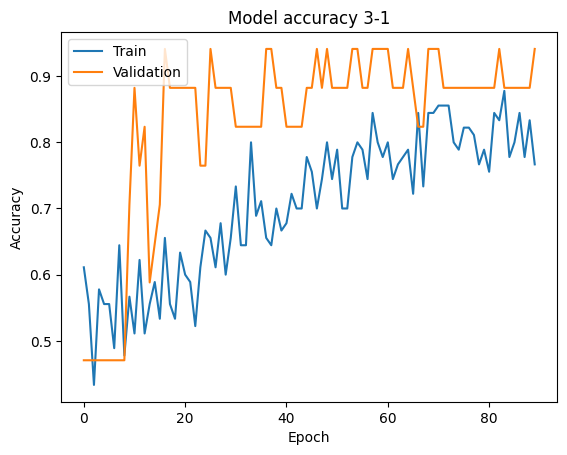

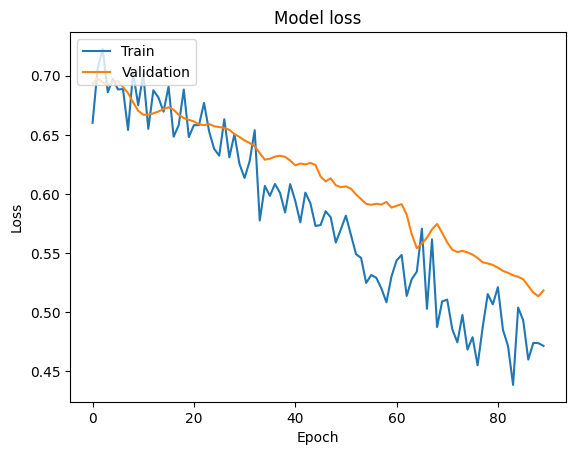

In [ ]:
# Performance evaluation curves for the last model

import matplotlib.pyplot as plt

# Plot training & validation accuracy values
#plt.figure(figsize=(10, 5))
#plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy 3-1')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()
# Plot training & validation loss values
#plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pickle  # Import the pickle module
# Save model
model_3_88 = '/content/drive/MyDrive/Prediction_T2D/Saved_Models/model_3_94.keras'  # Replace with your desired path
model.save(model_3_88)

# Save training history
history_save_path = '/content/drive/MyDrive/Prediction_T2D/Saved_Models/train_model_3_94.pkl'  # Replace with your desired path
with open(history_save_path, 'wb') as file:
    pickle.dump(model, file)
